In [28]:

from typing import List, TypedDict,Literal
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings
from pydantic import BaseModel,Field

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
docs = (
    PyPDFLoader("../documents/Company_Policies.pdf").load() +
    PyPDFLoader("../documents/Company_Profile.pdf").load() +
    PyPDFLoader("../documents/Product_and_Pricing.pdf").load()
)
docs


[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '../documents/Company_Policies.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x7f\nSick Leave: 10 working days per year\n\x7f\nCasual Leave: 6 working days per year\n\x7f\nMaternity Leave:

In [5]:
len(docs)

8

In [8]:
chunks = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=100).split_documents(docs)
chunks

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '../documents/Company_Policies.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x7f\nSick Leave: 10 working days per year\n\x7f'),
 Document(metadata={'producer': 'ReportLab PDF Library - ww

In [19]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = Chroma.from_documents(chunks,embeddings)
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4417.18it/s]


In [20]:
llm=ChatGroq(model="llama-3.1-8b-instant")
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")  #for structured output ...

In [58]:

# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]

    answer: str

In [78]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = model.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}



In [67]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }

In [68]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [69]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

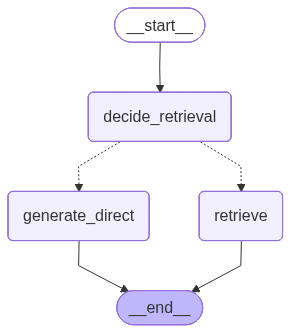

In [79]:

g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)
g.add_edge("retrieve", END)  # temporary END for retrieval path

app = g.compile()
app

In [80]:
result = app.invoke(
    {
        "question": "Who is the CEO of the NexaAI?",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

In [81]:
print(result['docs'])

[Document(id='9f233135-1b43-438b-8503-60e43be861e5', metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'moddate': '2026-02-14T13:07:17+00:00', 'creationdate': '2026-02-14T13:07:17+00:00', 'source': '../documents/Company_Profile.pdf', 'subject': '(unspecified)', 'trapped': '/False', 'total_pages': 2, 'author': '(anonymous)', 'title': '(anonymous)', 'page': 1, 'creator': '(unspecified)', 'page_label': '2', 'keywords': ''}, page_content='Founder\nAarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and\ncloud infrastructure.\nHe previously worked with global consulting firms where he led multiple large-scale digital\ntransformation projects.\nLeadership Team\nThe leadership team brings experience across AI engineering, product management, and business\noperations.\n\x7f\nAarav Mehta – CEO & Founder\n\x7f\nRiya Kapoor – CTO (Distributed systems & AI platforms)\n\x7f\nKunal Sharma – Head of Product\n\x7f'), Document(id='be43b903-4b9c-454